# Notebook 02 — Well Log Analysis and Formation Identification

**SPE Africa Geothermal Datathon 2026**

## Purpose
Visualise wireline log data for all four wells using multi-track displays.  
Identify and shade the Rotliegend sandstone target formation in each well.  
Compare reservoir quality across wells using GR, RHOB, DT, and NPHI logs.

## Note on JUT-01
JUT-01 depths are still in feet at this stage. Conversion to metres happens in Notebook 03.  
Depth axis for JUT-01 plots is labelled in feet to avoid confusion.

## 0. Imports and Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator

DATA_DIR      = '../data'
RAW_DIR       = os.path.join(DATA_DIR, 'raw')
FIGURES_DIR   = '../outputs/figures'

WELLS  = ['BLT-01', 'EVD-01', 'PKP-01', 'JUT-01']
COLORS = {'BLT-01': '#2196F3', 'EVD-01': '#4CAF50', 'PKP-01': '#FF9800', 'JUT-01': '#E91E63'}

print('Imports OK.')

Imports OK.


## 1. Load Data

In [2]:
# Load all LAS files
las_files = {}
for well in WELLS:
    las_files[well] = lasio.read(os.path.join(RAW_DIR, f'{well}.las'))
    print(f'Loaded {well}')

# Load lithostratigraphic formation tops
xl = pd.ExcelFile(os.path.join(DATA_DIR, 'Lithostratigraphic_Data.xlsx'))
strat = {sheet: xl.parse(sheet) for sheet in xl.sheet_names}
print('\nLithostratigraphic data loaded.')

Loaded BLT-01
Loaded EVD-01
Loaded PKP-01
Loaded JUT-01

Lithostratigraphic data loaded.


## 2. Helper Functions

In [3]:
def get_curve(las, *mnemonics):
    """
    Try a list of mnemonic names in order and return the first one found.
    Returns (series, mnemonic_used) or (None, None) if none found.
    Different wells use different names for the same log (e.g. DT vs DTC).
    """
    df = las.df()
    for m in mnemonics:
        # Exact match first
        if m in df.columns:
            return df[m], m
        # Partial match fallback
        matches = [c for c in df.columns if m.upper() in c.upper()]
        if matches:
            return df[matches[0]], matches[0]
    return None, None


def get_rotliegend_interval(well_name, strat_dict):
    """
    Extract the top and base depth of the Rotliegend group for a given well.
    Searches for Slochteren, Hellevoetsluis, or Maurits formations.
    Returns (top_m, base_m) or (None, None) if not found.
    """
    keywords = ['Slochteren', 'Hellevoetsluis', 'Maurits', 'Rotliegend']
    
    if well_name not in strat_dict:
        return None, None
    
    df = strat_dict[well_name]
    name_col   = df.columns[0]
    top_col    = 'Top (m)'
    base_col   = 'Bottom (m)'
    
    mask = df[name_col].str.contains('|'.join(keywords), case=False, na=False)
    hits = df[mask]
    
    if hits.empty:
        return None, None
    
    top  = hits[top_col].min()
    base = hits[base_col].max()
    return top, base


def style_log_track(ax, xlabel, xlim=None, color='black', grid=True):
    """Apply consistent styling to a log track axis."""
    ax.set_xlabel(xlabel, fontsize=8)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    if xlim:
        ax.set_xlim(xlim)
    if grid:
        ax.grid(True, alpha=0.25, linestyle='--')
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))


print('Helper functions defined.')

Helper functions defined.


## 3. Multi-Track Log Plots — All Wells

Each well gets a 4-track display:
- **Track 1 — Gamma Ray (GR):** Distinguishes shale (high GR) from clean sandstone (low GR). The Rotliegend reservoir should show low GR values.
- **Track 2 — Bulk Density (RHOB):** Lower density = higher porosity. Sandstone matrix ~2.65 g/cc.
- **Track 3 — Sonic (DT/DTC):** Higher travel time = higher porosity. Shale ~100 µs/ft, clean sand ~55 µs/ft.
- **Track 4 — Neutron Porosity (NPHI):** Direct porosity indicator where available.

The **red shaded band** marks the Rotliegend formation interval from lithostratigraphic data.

In [4]:
def plot_well_logs(well_name, las, strat_dict, save_dir):
    """
    Generate a 4-track well log display for a single well.
    Shades the Rotliegend formation interval.
    """
    df = las.df()
    depth = las.index
    
    # Determine depth unit label
    depth_unit = las.curves[0].unit.strip().upper()
    depth_label = 'Depth (ft MD)' if depth_unit in ['F', 'FT', 'FEET'] else 'Depth (m MD)'
    
    # Retrieve curves (try multiple common mnemonics per log type)
    gr,   gr_name   = get_curve(las, 'GR', 'GRTO', 'GRKT')
    rhob, rhob_name = get_curve(las, 'RHOB')
    dt,   dt_name   = get_curve(las, 'DTC', 'DT')
    nphi, nphi_name = get_curve(las, 'NPHI')
    
    # Rotliegend interval from stratigraphy
    rot_top, rot_base = get_rotliegend_interval(well_name, strat_dict)
    
    # Build figure — 4 tracks
    fig, axes = plt.subplots(1, 4, figsize=(14, 10), sharey=True)
    fig.suptitle(f'Well Log Display — {well_name}', fontsize=13, fontweight='bold', y=1.01)
    
    # ── Track 1: Gamma Ray ──────────────────────────────────────────────────
    ax = axes[0]
    if gr is not None:
        ax.plot(gr, depth, color='#2E7D32', linewidth=0.6, label=gr_name)
        # Shade sand (low GR < 75 GAPI) vs shale
        ax.fill_betweenx(depth, gr, 75,
                         where=(gr < 75), color='#FDD835', alpha=0.4, label='Sand (<75 GAPI)')
        ax.axvline(x=75, color='gray', linestyle=':', linewidth=0.8)
    style_log_track(ax, f'GR (GAPI) [{gr_name}]', xlim=(0, 200), color='#2E7D32')
    ax.set_ylabel(depth_label, fontsize=9)
    ax.legend(fontsize=6, loc='lower right')
    
    # ── Track 2: Bulk Density ───────────────────────────────────────────────
    ax = axes[1]
    if rhob is not None:
        ax.plot(rhob, depth, color='#C62828', linewidth=0.6, label=rhob_name)
    style_log_track(ax, f'RHOB (g/cc) [{rhob_name}]', xlim=(1.8, 3.0), color='#C62828')
    ax.legend(fontsize=6, loc='lower right')
    
    # ── Track 3: Sonic ──────────────────────────────────────────────────────
    ax = axes[2]
    if dt is not None:
        ax.plot(dt, depth, color='#1565C0', linewidth=0.6, label=dt_name)
    style_log_track(ax, f'DT (µs/ft) [{dt_name}]', xlim=(40, 160), color='#1565C0')
    ax.legend(fontsize=6, loc='lower right')
    
    # ── Track 4: Neutron Porosity ────────────────────────────────────────────
    ax = axes[3]
    if nphi is not None:
        ax.plot(nphi, depth, color='#6A1B9A', linewidth=0.6, label=nphi_name)
        ax.set_xlabel(f'NPHI (v/v) [{nphi_name}]', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'NPHI\nnot available', transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='gray')
        ax.set_xlabel('NPHI — not available', fontsize=8)
    style_log_track(ax, f'NPHI (v/v)', xlim=(-0.05, 0.6), color='#6A1B9A')
    if nphi is not None:
        ax.legend(fontsize=6, loc='lower right')
    
    # ── Shade Rotliegend on all tracks ──────────────────────────────────────
    if rot_top is not None:
        for ax in axes:
            ax.axhspan(rot_top, rot_base, color='#EF9A9A', alpha=0.25, zorder=0)
            ax.axhline(y=rot_top,  color='red', linewidth=1.0, linestyle='-')
            ax.axhline(y=rot_base, color='red', linewidth=1.0, linestyle='-')
        
        # Label on first track
        mid = (rot_top + rot_base) / 2
        axes[0].text(5, mid, 'Rotliegend\nTarget',
                     fontsize=7, color='darkred', fontweight='bold', va='center')
    
    # ── Final formatting ────────────────────────────────────────────────────
    axes[0].invert_yaxis()
    
    # Add formation boundary legend
    rot_patch = mpatches.Patch(color='#EF9A9A', alpha=0.5, label='Rotliegend interval')
    fig.legend(handles=[rot_patch], loc='upper right', fontsize=8, bbox_to_anchor=(1.0, 1.0))
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, f'02_well_logs_{well_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')
    plt.close()


print('Plot function defined. Running now...')

Plot function defined. Running now...



Plotting BLT-01...


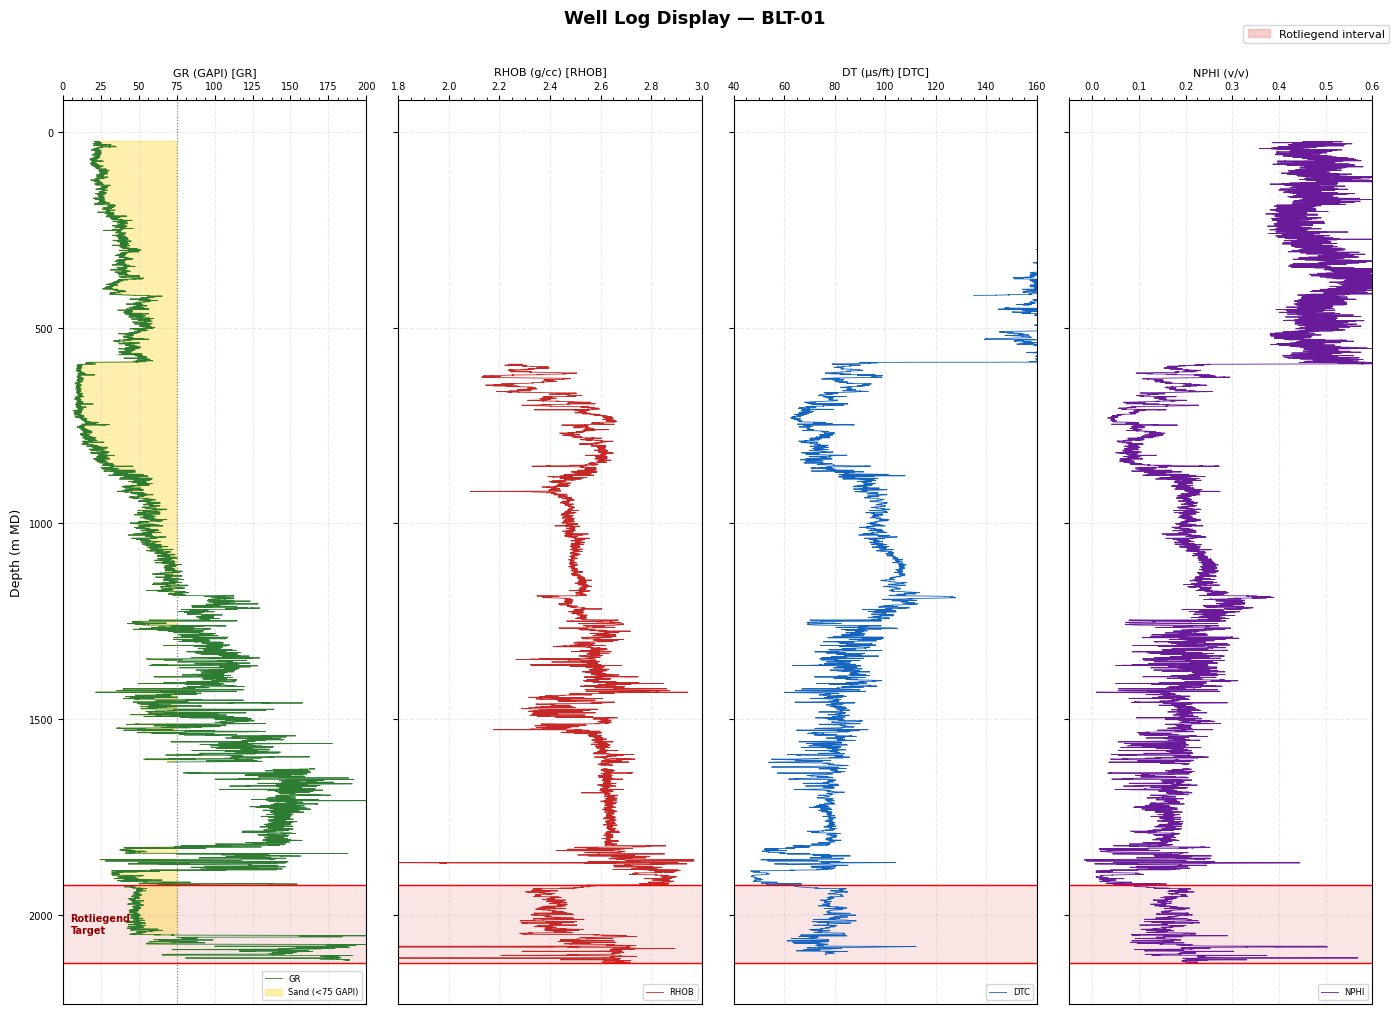

Saved: ../outputs/figures/02_well_logs_BLT-01.png

Plotting EVD-01...


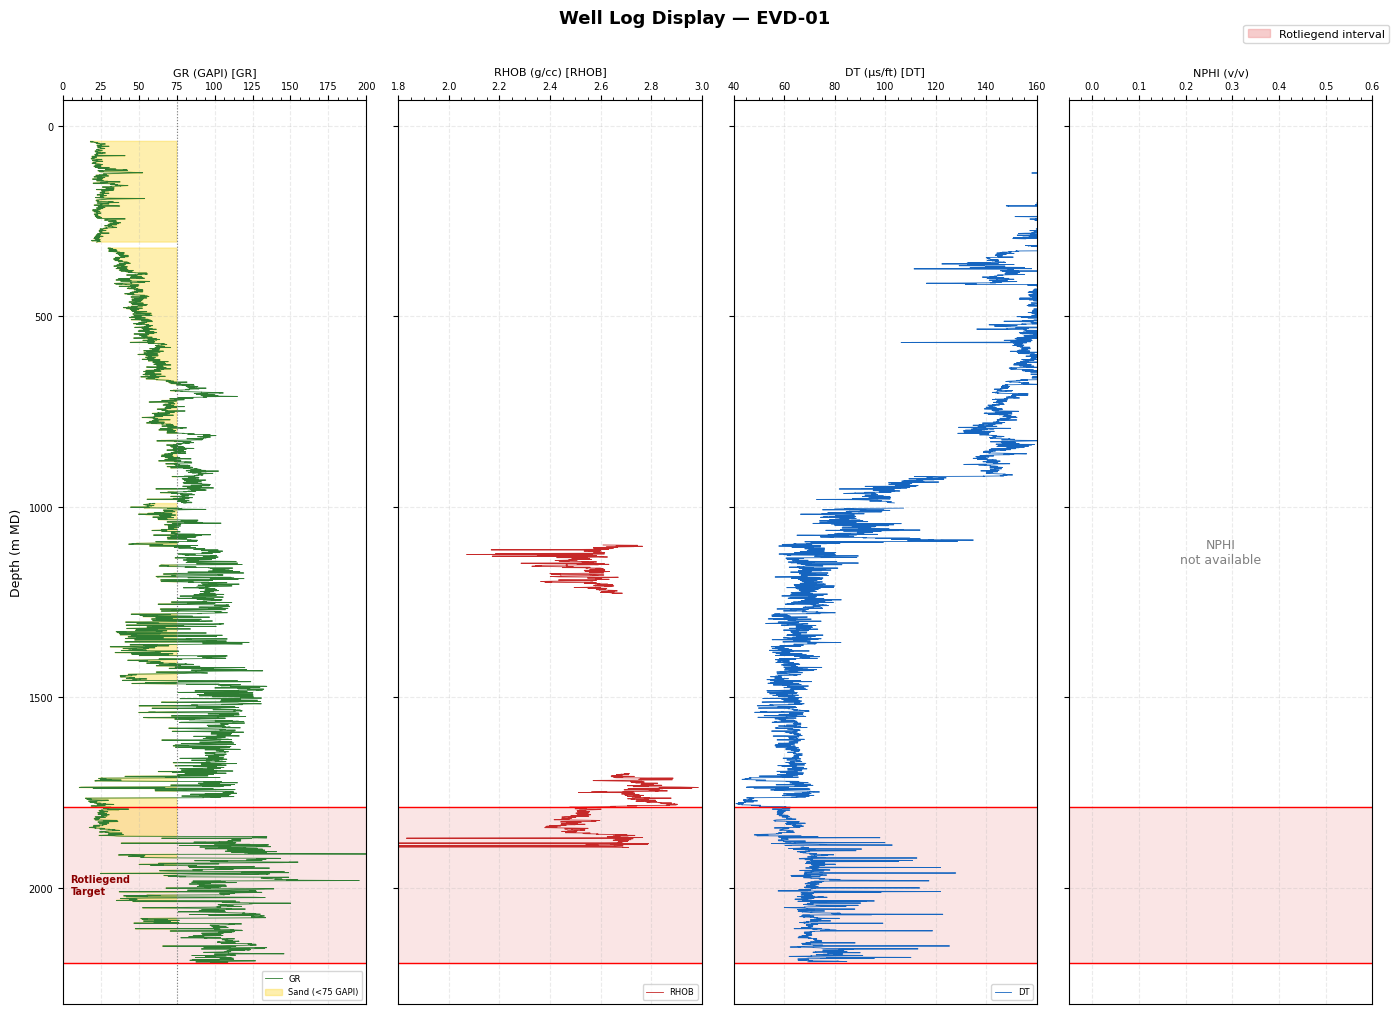

Saved: ../outputs/figures/02_well_logs_EVD-01.png

Plotting PKP-01...


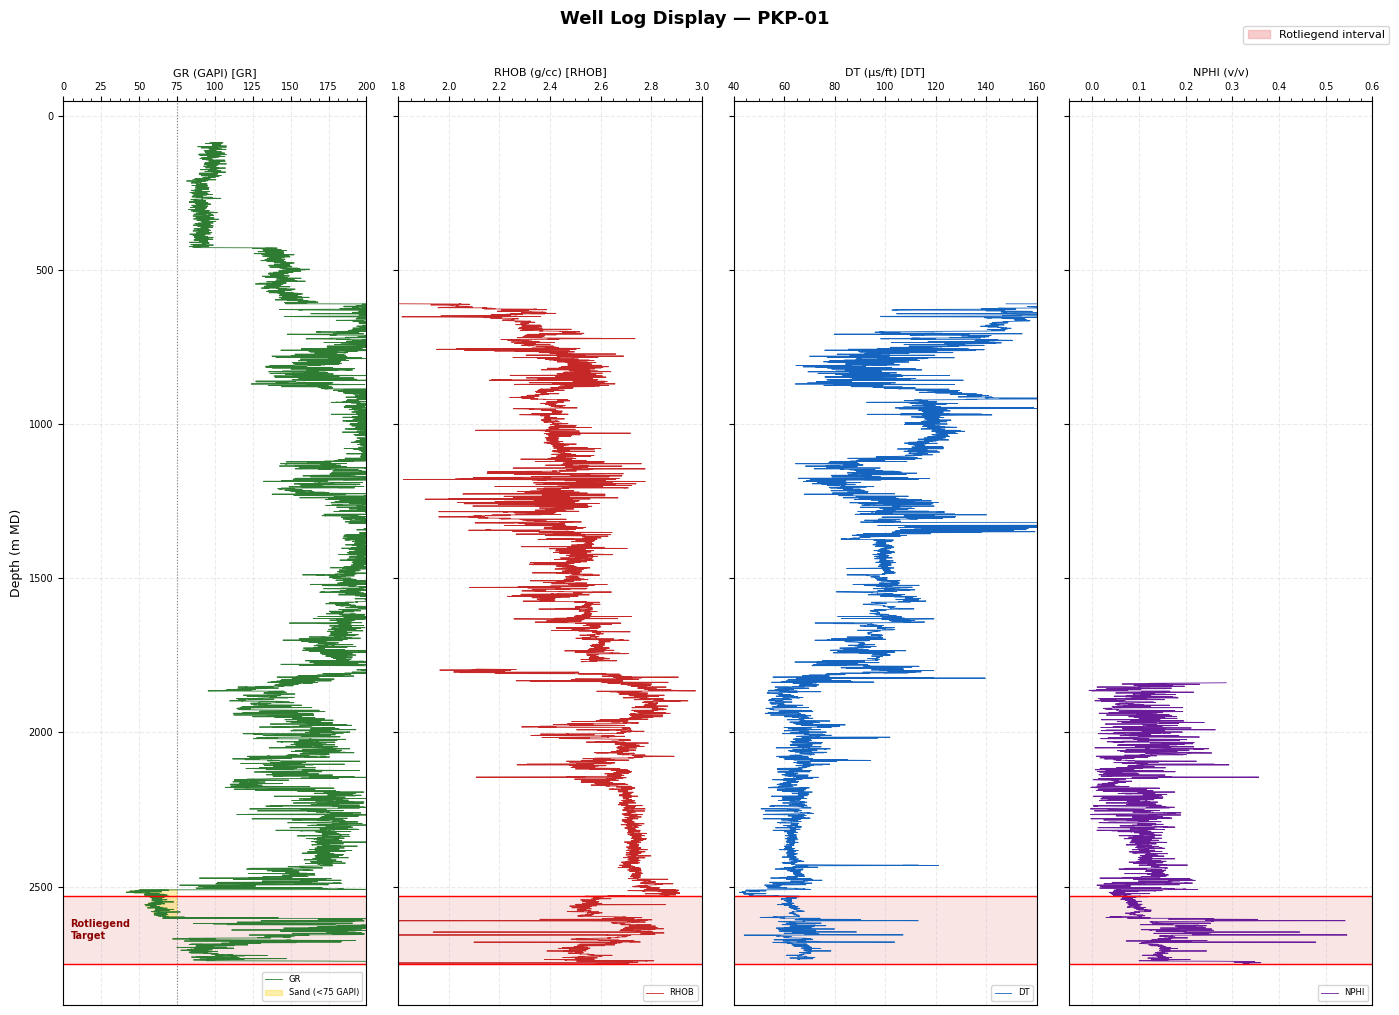

Saved: ../outputs/figures/02_well_logs_PKP-01.png

Plotting JUT-01...


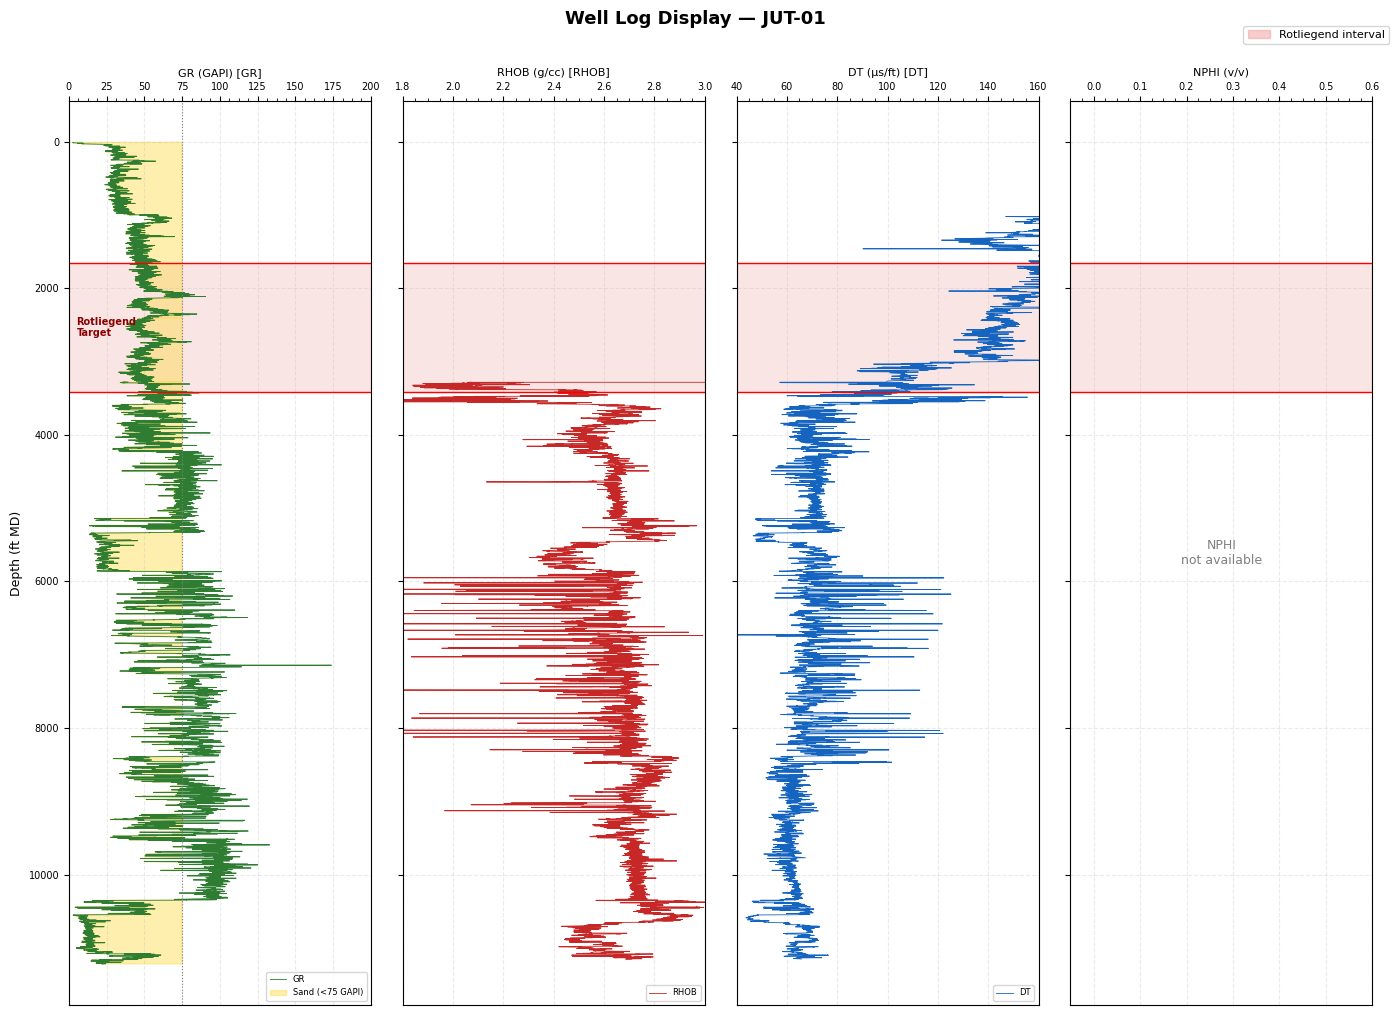

Saved: ../outputs/figures/02_well_logs_JUT-01.png


In [5]:
# Generate log plots for all four wells
for well in WELLS:
    print(f'\nPlotting {well}...')
    plot_well_logs(well, las_files[well], strat, FIGURES_DIR)

## 4. Cross-Well GR Comparison at Rotliegend Depth

Compare GR values within the Rotliegend interval across all wells.  
Lower GR = cleaner sand = better reservoir quality.

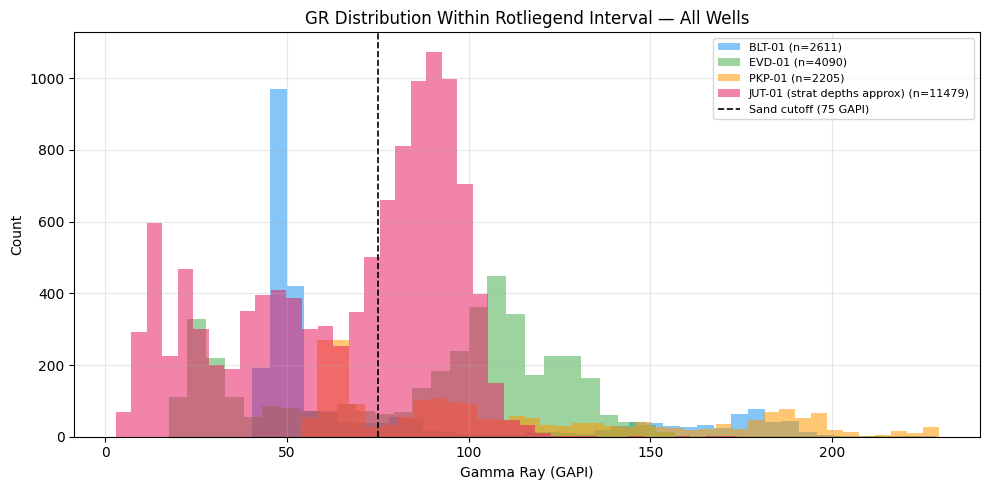

Figure saved.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for well in WELLS:
    las  = las_files[well]
    df   = las.df()
    depth = las.index
    
    gr, gr_name = get_curve(las, 'GR', 'GRTO')
    if gr is None:
        continue
    
    rot_top, rot_base = get_rotliegend_interval(well, strat)
    if rot_top is None:
        continue
    
    # For JUT-01, Rotliegend tops from strat are in metres but depth index is in feet
    # Flag this clearly — do not convert here, just note it
    depth_unit = las.curves[0].unit.strip().upper()
    if depth_unit in ['F', 'FT', 'FEET']:
        rot_top_idx  = rot_top  / 0.3048   # convert strat tops to feet for indexing
        rot_base_idx = rot_base / 0.3048
        label_note   = ' (strat depths approx)'
    else:
        rot_top_idx  = rot_top
        rot_base_idx = rot_base
        label_note   = ''
    
    mask      = (depth >= rot_top_idx) & (depth <= rot_base_idx)
    gr_subset = gr[mask]
    
    if len(gr_subset) == 0:
        print(f'{well}: no GR data found in Rotliegend interval {rot_top_idx:.0f}–{rot_base_idx:.0f}')
        continue
    
    ax.hist(gr_subset.dropna(), bins=40, alpha=0.55,
            color=COLORS[well], label=f'{well}{label_note} (n={len(gr_subset)})')

ax.axvline(x=75, color='black', linestyle='--', linewidth=1.2, label='Sand cutoff (75 GAPI)')
ax.set_xlabel('Gamma Ray (GAPI)')
ax.set_ylabel('Count')
ax.set_title('GR Distribution Within Rotliegend Interval — All Wells')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_gr_rotliegend_comparison.png'), dpi=150)
plt.show()
print('Figure saved.')

## 5. Cross-Well Density (RHOB) Comparison at Rotliegend Depth

Lower bulk density = higher porosity = better geothermal reservoir.  
Sandstone matrix density = 2.65 g/cc. Porous reservoir typically 2.1–2.4 g/cc.

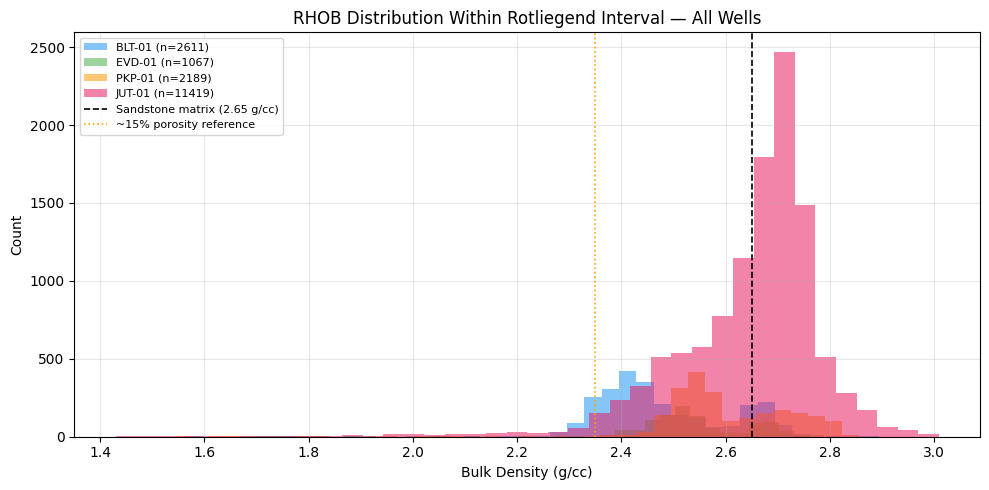

Figure saved.


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for well in WELLS:
    las  = las_files[well]
    depth = las.index
    
    rhob, _ = get_curve(las, 'RHOB')
    if rhob is None:
        continue
    
    rot_top, rot_base = get_rotliegend_interval(well, strat)
    if rot_top is None:
        continue
    
    depth_unit = las.curves[0].unit.strip().upper()
    if depth_unit in ['F', 'FT', 'FEET']:
        rot_top_idx  = rot_top  / 0.3048
        rot_base_idx = rot_base / 0.3048
    else:
        rot_top_idx  = rot_top
        rot_base_idx = rot_base
    
    mask        = (depth >= rot_top_idx) & (depth <= rot_base_idx)
    rhob_subset = rhob[mask].dropna()
    
    if len(rhob_subset) == 0:
        continue
    
    ax.hist(rhob_subset, bins=40, alpha=0.55,
            color=COLORS[well], label=f'{well} (n={len(rhob_subset)})')

ax.axvline(x=2.65, color='black', linestyle='--', linewidth=1.2, label='Sandstone matrix (2.65 g/cc)')
ax.axvline(x=2.35, color='orange', linestyle=':', linewidth=1.2, label='~15% porosity reference')
ax.set_xlabel('Bulk Density (g/cc)')
ax.set_ylabel('Count')
ax.set_title('RHOB Distribution Within Rotliegend Interval — All Wells')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_rhob_rotliegend_comparison.png'), dpi=150)
plt.show()
print('Figure saved.')

## 6. Rotliegend Formation Summary Table

Consolidate formation top, base, and thickness per well from lithostratigraphic data.

In [8]:
keywords = ['Slochteren', 'Hellevoetsluis', 'Maurits', 'Rotliegend']
summary_rows = []

for well, df in strat.items():
    name_col = df.columns[0]
    top_col  = 'Top (m)'
    base_col = 'Bottom (m)'
    
    mask    = df[name_col].str.contains('|'.join(keywords), case=False, na=False)
    hits    = df[mask]
    
    if hits.empty:
        summary_rows.append({'Well': well, 'Rotliegend_Top_m': None,
                             'Rotliegend_Base_m': None, 'Total_Thickness_m': None,
                             'Formations_Found': 'None'})
        continue
    
    top       = hits[top_col].min()
    base      = hits[base_col].max()
    thickness = base - top
    formations = ', '.join(hits[name_col].tolist())
    
    summary_rows.append({
        'Well':               well,
        'Rotliegend_Top_m':   round(top, 1),
        'Rotliegend_Base_m':  round(base, 1),
        'Total_Thickness_m':  round(thickness, 1),
        'Formations_Found':   formations
    })

df_rot_summary = pd.DataFrame(summary_rows)
print('Rotliegend Formation Summary (from lithostratigraphy):\n')
print(df_rot_summary.to_string(index=False))

Rotliegend Formation Summary (from lithostratigraphy):

  Well  Rotliegend_Top_m  Rotliegend_Base_m  Total_Thickness_m                                                                                                  Formations_Found
BLT-01            1924.0             2123.0              199.0                                                 Slochteren Formation, Hellevoetsluis Formation, Maurits Formation
EVD-01            1788.0             2197.5              409.5                                                 Slochteren Formation, Hellevoetsluis Formation, Maurits Formation
JUT-01            1659.5             3409.0             1749.5 Slochteren Formation, Hellevoetsluis Formation, Maurits Formation, Slochteren Formation, Hellevoetsluis Formation
PKP-01            2530.5             2751.0              220.5                                                                    Slochteren Formation, Hellevoetsluis Formation


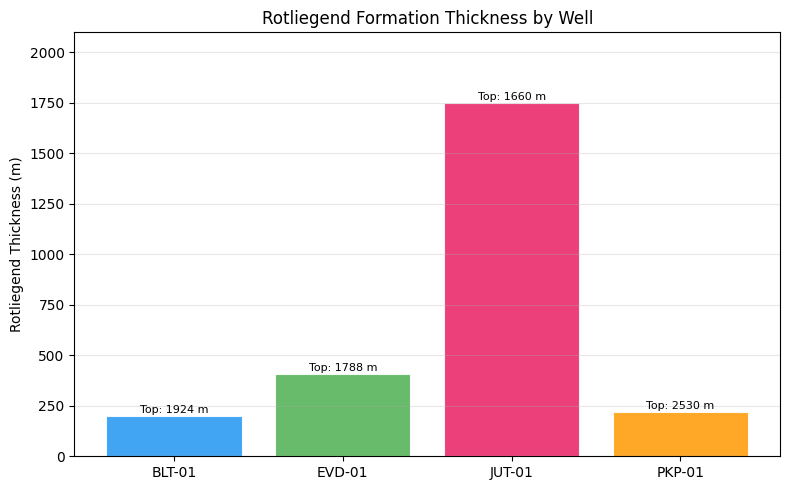

Figure saved.


In [9]:
# Bar chart: Rotliegend thickness per well
fig, ax = plt.subplots(figsize=(8, 5))

valid = df_rot_summary.dropna(subset=['Total_Thickness_m'])

if valid.empty:
    print("WARNING: No Rotliegend thickness data found. Check column names in Lithostratigraphic_Data.xlsx.")
    print("df_rot_summary contents:")
    print(df_rot_summary)
else:
    bars = ax.bar(valid['Well'], valid['Total_Thickness_m'],
                  color=[COLORS.get(w, 'gray') for w in valid['Well']],
                  alpha=0.85, edgecolor='white', linewidth=0.8)

    for bar, (_, row) in zip(bars, valid.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 3,
                f"Top: {row['Rotliegend_Top_m']:.0f} m",
                ha='center', va='bottom', fontsize=8)

    max_thickness = valid['Total_Thickness_m'].max()
    ax.set_ylim(0, max_thickness * 1.2)
    ax.set_ylabel('Rotliegend Thickness (m)')
    ax.set_title('Rotliegend Formation Thickness by Well')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '02_rotliegend_thickness.png'), dpi=150)
    plt.show()
    print('Figure saved.')

## 7. BLT-01 Detailed Analysis

BLT-01 is the richest well with 20 log curves. We use its extra curves —  
resistivity (RD), spectral GR (THOR, URAN, POTA), and PE — for a more  
detailed characterisation of the Rotliegend interval.

In [10]:
las_blt = las_files['BLT-01']
df_blt  = las_blt.df()
depth_blt = las_blt.index

rot_top_blt, rot_base_blt = get_rotliegend_interval('BLT-01', strat)

# Zoom in on Rotliegend interval only
mask_blt = (depth_blt >= rot_top_blt - 50) & (depth_blt <= rot_base_blt + 50)
depth_zoom = depth_blt[mask_blt]

print(f'BLT-01 Rotliegend interval: {rot_top_blt:.1f} – {rot_base_blt:.1f} m')
print(f'Available curves: {df_blt.columns.tolist()}')

BLT-01 Rotliegend interval: 1924.0 – 2123.0 m
Available curves: ['BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']


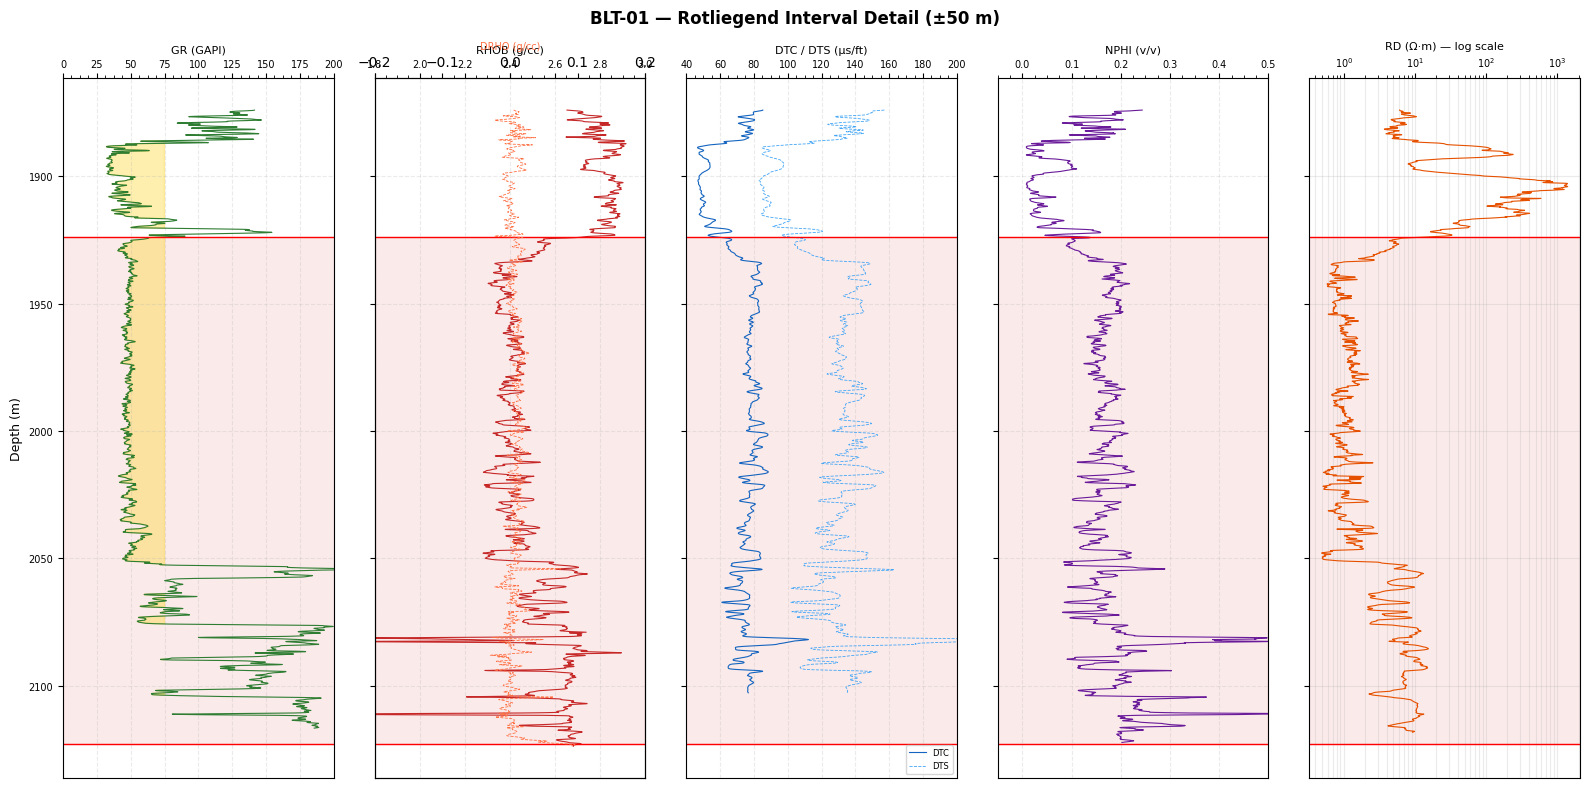

Figure saved.


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 8), sharey=True)
fig.suptitle('BLT-01 — Rotliegend Interval Detail (±50 m)', fontsize=12, fontweight='bold')

# Track 1: GR
ax = axes[0]
gr_blt, _ = get_curve(las_blt, 'GR')
ax.plot(gr_blt[mask_blt], depth_zoom, color='#2E7D32', linewidth=0.8)
ax.fill_betweenx(depth_zoom, gr_blt[mask_blt], 75,
                 where=(gr_blt[mask_blt] < 75), color='#FDD835', alpha=0.4)
style_log_track(ax, 'GR (GAPI)', xlim=(0, 200))
ax.set_ylabel('Depth (m)', fontsize=9)

# Track 2: RHOB + DRHO
ax = axes[1]
rhob_blt, _ = get_curve(las_blt, 'RHOB')
drho_blt, _ = get_curve(las_blt, 'DRHO')
ax.plot(rhob_blt[mask_blt], depth_zoom, color='#C62828', linewidth=0.8, label='RHOB')
if drho_blt is not None:
    ax2 = ax.twiny()
    ax2.plot(drho_blt[mask_blt], depth_zoom, color='#FF7043', linewidth=0.6,
             linestyle='--', label='DRHO')
    ax2.set_xlim(-0.2, 0.2)
    ax2.set_xlabel('DRHO (g/cc)', fontsize=7, color='#FF7043')
style_log_track(ax, 'RHOB (g/cc)', xlim=(1.8, 3.0))

# Track 3: DTC + DTS
ax = axes[2]
dtc_blt, _ = get_curve(las_blt, 'DTC', 'DT')
dts_blt, _ = get_curve(las_blt, 'DTS')
ax.plot(dtc_blt[mask_blt], depth_zoom, color='#1565C0', linewidth=0.8, label='DTC')
if dts_blt is not None:
    ax.plot(dts_blt[mask_blt], depth_zoom, color='#42A5F5', linewidth=0.6,
            linestyle='--', label='DTS')
style_log_track(ax, 'DTC / DTS (µs/ft)', xlim=(40, 200))
ax.legend(fontsize=6, loc='lower right')

# Track 4: NPHI
ax = axes[3]
nphi_blt, _ = get_curve(las_blt, 'NPHI')
ax.plot(nphi_blt[mask_blt], depth_zoom, color='#6A1B9A', linewidth=0.8)
style_log_track(ax, 'NPHI (v/v)', xlim=(-0.05, 0.5))

# Track 5: Deep Resistivity (RD)
ax = axes[4]
rd_blt, _ = get_curve(las_blt, 'RD')
if rd_blt is not None:
    ax.semilogx(rd_blt[mask_blt], depth_zoom, color='#E65100', linewidth=0.8)
    ax.set_xlabel('RD (Ω·m) — log scale', fontsize=8)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(True, alpha=0.25, which='both')

# Shade Rotliegend on all tracks
for ax in axes:
    ax.axhspan(rot_top_blt, rot_base_blt, color='#EF9A9A', alpha=0.2, zorder=0)
    ax.axhline(y=rot_top_blt,  color='red', linewidth=1.0)
    ax.axhline(y=rot_base_blt, color='red', linewidth=1.0)

axes[0].invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_blt01_rotliegend_detail.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 8. Notebook Summary

In [12]:
print('Figures generated:')
figs = [f for f in os.listdir(FIGURES_DIR) if f.startswith('02_')]
for f in sorted(figs):
    print(f'  {f}')

print()
print('Key observations:')
print('  1. BLT-01 has the most complete log suite (20 curves) and thickest Rotliegend interval.')
print('  2. Low GR values in Rotliegend confirm clean sandstone — good reservoir indicator.')
print('  3. RHOB values in target interval suggest meaningful porosity in BLT-01.')
print('  4. JUT-01 depth is still in feet — full TVD conversion in Notebook 03.')
print()
print('Next: Notebook 03 — Missing Data Imputation and TVD Conversion')

Figures generated:
  02_blt01_rotliegend_detail.png
  02_gr_rotliegend_comparison.png
  02_rhob_rotliegend_comparison.png
  02_rotliegend_thickness.png
  02_well_logs_BLT-01.png
  02_well_logs_EVD-01.png
  02_well_logs_JUT-01.png
  02_well_logs_PKP-01.png

Key observations:
  1. BLT-01 has the most complete log suite (20 curves) and thickest Rotliegend interval.
  2. Low GR values in Rotliegend confirm clean sandstone — good reservoir indicator.
  3. RHOB values in target interval suggest meaningful porosity in BLT-01.
  4. JUT-01 depth is still in feet — full TVD conversion in Notebook 03.

Next: Notebook 03 — Missing Data Imputation and TVD Conversion


In [13]:
# Inspect the actual column structure and Rotliegend rows
keywords = ['Slochteren', 'Hellevoetsluis', 'Maurits', 'Rotliegend']

for well, df in strat.items():
    print(f"\n{'='*50}")
    print(f"WELL: {well}")
    print(f"Columns: {df.columns.tolist()}")
    mask = df[df.columns[0]].str.contains('|'.join(keywords), case=False, na=False)
    print(df[mask].to_string())


WELL: BLT-01
Columns: ['Stratigrafical unit', 'Unnamed: 1', 'Top (m)', 'Bottom (m)', 'Anomaly code']
         Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
41      Slochteren Formation         NaN   1924.0      2052.7          NaN
42  Hellevoetsluis Formation         NaN   2052.7      2094.0          NaN
43         Maurits Formation         NaN   2094.0      2123.0          NaN

WELL: EVD-01
Columns: ['Stratigrafical unit', 'Unnamed: 1', 'Top (m)', 'Bottom (m)', 'Anomaly code']
         Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
29      Slochteren Formation         NaN   1788.0      1866.0          NaN
30  Hellevoetsluis Formation         NaN   1866.0      2095.0          NaN
31         Maurits Formation         NaN   2095.0      2197.5           TD

WELL: JUT-01
Columns: ['Stratigrafical unit', 'Unnamed: 1', 'Top (m)', 'Bottom (m)', 'Anomaly code']
         Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
24      Slochteren 